In [11]:
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../"))
if project_root not in sys.path:
    sys.path.append(project_root)

In [12]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from diffusion.schedules import LinearVS
from diffusion.forward import ForwardVP
from diffusion.reverse import ReverseVP
from score_nets.muller_brown_net import MullerBrownNet
from data.loaders.muller_brown_data import (MullerBrownPotential, langevin_sampling, MolecularDataset, 
                                            generate_muller_brown_data, MullerBrownEvaluator)
from trainers.muller_brown_trainer import MBTrainer
from trainers.mb_dist import MBDistillationTrainer
from samplers.muller_brown_sampler import MBSampler
from physics.derive_noise import noise_from_energy
from physics.derive_score import score_from_energy
from physics.drift_score_gate import fp_gate
from physics.fp_gate import FPGate
from physics.fp_residuals import mb_heavy_fp_residual, mb_light_fp_residual
from losses.dsm_losses import mse_loss
from losses.fp_losses import mb_fokker_planck_loss
from losses.distillation_loss import mb_distillation_loss

#### in this notebook we will train three models on Müller-Brwon (2D toy) dataset with different experimental conditions. here we want to see if classical iid diffusion sampling  correctly reproduces modes of data and evaluating the score at t -> 0 to estimate the unnormalized density yields a correct mass distribution. here we will train different diffusion models with fp-regularization and without.

##### 1) in the first experiment we will train a diffusion model without applying fokker-planck regularization
##### 2) in the third experiment we will train a diffusion model with fp-regularization which is applied throuth an untrainable gate 
##### 3) in the third experiment we will distill the result of fp-regularized model to a faster sampler.

#### after all experiments are done we will analyze their performance in both conventional iid sampling and also langevin-dynamics sampling.

#### Data Preparation

#### here we generate a dataset of 100K samples, each sample is a 2d point with x and y coordinates, the entire dataset represents equalibriums of a sample (a point) through time , we will store once every 50 steps, which means to create this dataset we must run langevin-dynamics simulation for 5000K ( + 500K burn in steps). this means:
#####  1) One long MD simulation (5.5M steps)
#####  2) 100k snapshots saved from that simulation
#####  3) Each snapshot = (x, y) at one moment in time
#####  4) Collection shows equilibrium distribution

In [13]:
# global hyperparams
DEVICE = 'cuda'
# langevin simulation specific parameters
DT = 0.005
MASS = 0.5
GAMMA = 1.0
BURN_IN_RATIO = 0.5
KBT = 23.0
# diffusion network specific parameters
INPUT_DIM = 2
HIDDEN_DIM = 128
TIME_EMBED_DIM = 128
NUM_BLOCKS = 3
ACTIVATION = 'silu'
# data parameters
BATCH_SIZE = 128
# training
EPOCHS = 180
LR = 5e-5
GRAD_ACC = 2
WARMUP_STEPS = 10000

EPS_TIME = 1e-5 # we will use this to bound diffusion time for both trining and sampling (eps_time, 1) for stability reasons

In [14]:
# it toke about 6 hours with my system (Intel i5‑9300HF CPU and an NVIDIA GTX 1650 (4 GB VRAM)) to generate dataset
# you can load it (set force_regenerate=False) but you can also generate your own data (force_regenerate=True)
dataset, potential = generate_muller_brown_data(
    n_samples = 100000,
    dt = DT,
    mass = MASS,
    save_every = 50,     
    kbt = KBT,
    log_freq = 500000,
    device = DEVICE,
    burn_in = 500000,   
    save_data = True,  
    save_dir = './mb_data',
    filename = 'muller_brown_100k.pt',
    force_regenerate = False
)

Found existing dataset at mb_data/muller_brown_100k.pt
Loading existing dataset (use force_regenerate=True to regenerate)
✓ Dataset loaded from: mb_data/muller_brown_100k.pt
  - Number of samples: 100000
  - Sample shape: torch.Size([100000, 2])
  - Mean: tensor([-0.3946,  1.0799])
  - Std: tensor([0.4914, 0.5687])


In [15]:
dataloader = DataLoader(
    dataset,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = 1, 
    drop_last = True
)

##### as you see from the visulaization the dataset has three modes, with more points focus on the corner modes.

### FIRST EXPERIMENT: Train a model without fokker-planck regularization (only DSM loss)
##### for the first model we will train a vp-sde diffusion model with linear schedular without applying fp-regularization, this is the base model and all other models will be compare to this one as reference model.

In [51]:
vs = LinearVS(beta_min = 0.1, beta_max = 20.0) # linear schedular with min and max beta (0.1, 20.0)

fwd = ForwardVP(vs) # forward diffusion which applies forward process of vp-sde (adding noise gradually to the data)

# we will train a relative small network 
fp_free_net = MullerBrownNet(
    input_dim = INPUT_DIM,
    time_embed_dim = TIME_EMBED_DIM,
    hidden_dim = HIDDEN_DIM,
    num_blocks = NUM_BLOCKS,
    activation = ACTIVATION 
)
#c = torch.load('fp_free_train/mb_epoch_180.pth')
#fp_free_net.load_state_dict(c['mb_net_state'])

print(sum(p.numel() for p in fp_free_net.parameters())) # sum of all trainable parameters of the diffusion network (which in this case is a noise predictor)

optim = torch.optim.Adam([p for p in fp_free_net.parameters()], lr=LR)


fp_free_trainer = MBTrainer(
    mb_net = fp_free_net,
    fwd = fwd,
    data_loader = dataloader,
    optim = optim,
    fp_gate = fp_gate,
    fp_loss = mb_fokker_planck_loss, # fokker planck loss
    noise_fn = noise_from_energy, # computes noise from energy
    fp_resid = mb_heavy_fp_residual, # computes weak fokker-planck residuals
    epochs = EPOCHS,
    device = torch.device(DEVICE),
    grad_acc = GRAD_ACC,
    checkpoint = 10,
    log_freq = 10,
    store_path  = "./fp_free_train",
    warmup_steps = WARMUP_STEPS,
    fp_alpha = 5e-4,
    eps_time = EPS_TIME,
    gate_params = {"k": 1.2, "snr_min": 0.5, "t_scale": 0.0, "sharpness": 5.0, "eps": 0.1}, # we set t_scale = 0, this prevents fp computation and application
)

134529


In [11]:
# lets start tarining
fp_free_losses = fp_free_trainer()

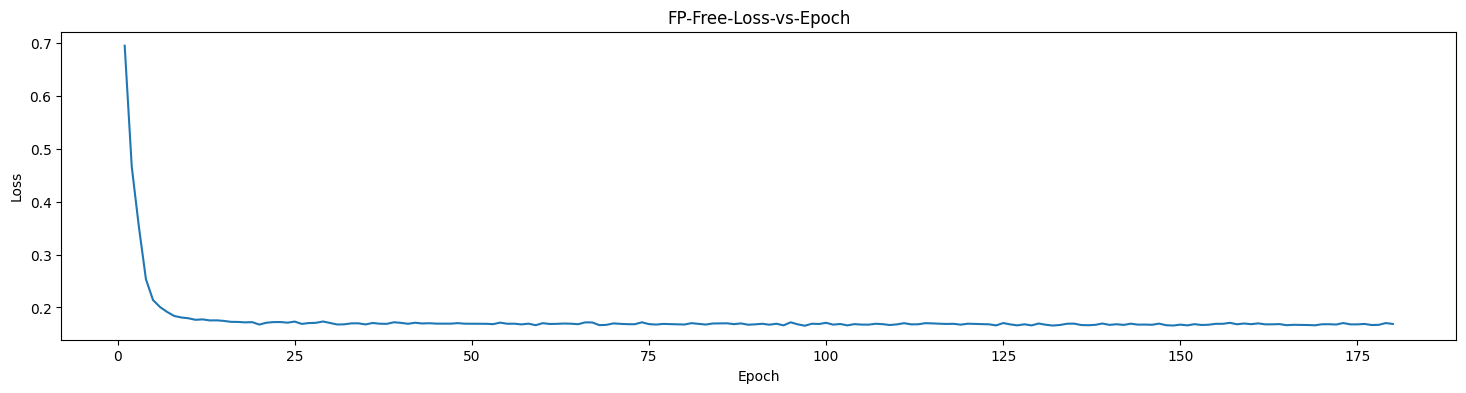

In [13]:
# losses is a dictionary contains total_losses, dsm_losses and fp_losses, here we visulaize total_losses which is equal to dsm_loss (no fp_loss colculation)
plt.figure(figsize=(18, 4))
plt.plot([i for i in range(1, 181)], fp_free_losses['total_losses'])
plt.title('FP-Free-Loss-vs-Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

#### now we will sample both iid and langevin from the trained model and see how it preforms

In [29]:
rev = ReverseVP(vs)
fp_free_sampler = MBSampler(
    model = fp_free_net,
    rev = rev,
    dataset_mean = dataset.mean,
    dataset_std = dataset.std,
    eps_time = EPS_TIME,
    store_path = "./fp_free_samples",
    kbt = KBT
)

IID Sampling: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 999/999 [00:33<00:00, 30.07it/s]


Results saved to ./fp_free_samples/sample_50000_iid.pth


Langevin Simulation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30000/30000 [01:59<00:00, 250.24it/s]


Results saved to ./fp_free_samples/sample_100_langevin.pth


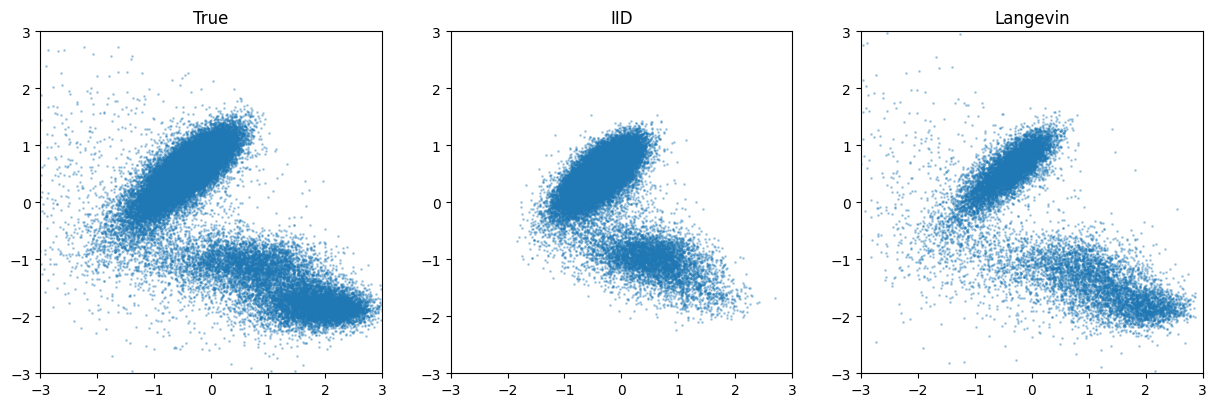

In [36]:
true_samples = dataset.samples 

iid_samples = fp_free_sampler.iid_sampler(
    n_samples = 50000,
    device = DEVICE,
    store_trajectory = False,
    return_original_space = False  
)


lan_samples = fp_free_sampler.langevin_simulator(
    n_parallel = 100,
    n_steps = 30000,
    dt = DT,
    mass = MASS,
    gamma = GAMMA,
    device = DEVICE,
    save_every = 100,
    burn_in_ratio = BURN_IN_RATIO,
    return_original_space = False 
)


N = 50000

true_subset = true_samples[torch.randperm(len(true_samples))[:N]]
lan_subset = lan_samples[torch.randperm(len(lan_samples))[:N]]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

X_LIM = (-3, 3)
Y_LIM = (-3, 3)

for ax, (name, samples) in zip(axes, [
    ("True", true_subset),
    ("IID", iid_samples),
    ("Langevin", lan_subset)
]):
    x = samples[:, 0].cpu().numpy()
    y = samples[:, 1].cpu().numpy()

    ax.scatter(x, y, alpha=0.3, s=1)

    ax.set_xlim(X_LIM)
    ax.set_ylim(Y_LIM)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(name)


plt.savefig('fp_free_sampling.png')

### SECOND EXPERIMENT: Train a model with fokker-planck regularization through a non-trainable gate
##### for the second model we will train a vp-sde diffusion model with linear schedular and applying fp-regularization through a non-trainable gate and also dsm loss. this means total loss is a combination of dsm-loss and fp-loss.

In [16]:
vs = LinearVS(beta_min = 0.1, beta_max = 20.0) # linear schedular with min and max beta (0.1, 20.0)

fwd = ForwardVP(vs) # forward diffusion which applies forward process of vp-sde (adding noise gradually to the data)

# we will train a relative small network 
fp_net = MullerBrownNet(
    input_dim = INPUT_DIM,
    time_embed_dim = TIME_EMBED_DIM,
    hidden_dim = HIDDEN_DIM,
    num_blocks = NUM_BLOCKS,
    activation = ACTIVATION 
)
c = torch.load('fp_train/mb_epoch_180.pth')
fp_net.load_state_dict(c['mb_net_state'])

print(sum(p.numel() for p in fp_net.parameters())) # sum of all trainable parameters of the diffusion network (which in this case is a noise predictor)

optim = torch.optim.Adam([p for p in fp_net.parameters()], lr=LR)


fp_trainer = MBTrainer(
    mb_net = fp_net,
    fwd = fwd,
    data_loader = dataloader,
    optim = optim,
    fp_gate = fp_gate,
    fp_loss = mb_fokker_planck_loss, # fokker planck loss
    noise_fn = noise_from_energy, # computes noise from energy
    fp_resid = mb_heavy_fp_residual, # computes weak fokker-planck residuals
    epochs = EPOCHS,
    device = torch.device(DEVICE),
    grad_acc = GRAD_ACC,
    checkpoint = 10,
    log_freq = 10,
    store_path  = "./fp_train",
    warmup_steps = WARMUP_STEPS,
    fp_alpha = 5e-3,
    eps_time = EPS_TIME,
    gate_params = {"k": 1.0, "snr_min": 0.5, "t_scale": 0.1, "sharpness": 8.0, "eps": 0.1}, # we set t_scale = 0.1, this trigers fp computation
)

134529


In [44]:
fp_losses = fp_trainer()

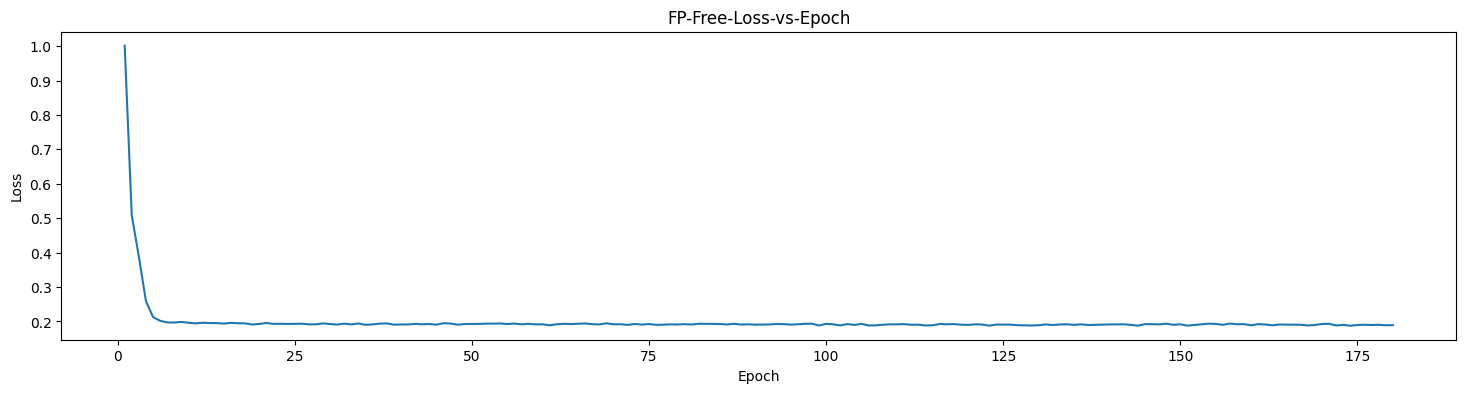

In [39]:
plt.figure(figsize=(18, 4))
plt.plot([i for i in range(1, 181)], fp_losses['total_losses'])
plt.title('FP-Free-Loss-vs-Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

#### now we will sample both iid and langevin from the trained model and see how it preforms

In [7]:
rev = ReverseVP(vs)
fp_sampler = MBSampler(
    model = fp_net,
    rev = rev,
    dataset_mean = dataset.mean,
    dataset_std = dataset.std,
    eps_time = EPS_TIME,
    store_path = "./fp_sample1s",
    kbt = KBT
)

IID Sampling: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 999/999 [00:34<00:00, 29.37it/s]


Results saved to ./fp_sample1s/sample_50000_iid.pth


Langevin Simulation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30000/30000 [01:57<00:00, 254.39it/s]


Results saved to ./fp_sample1s/sample_100_langevin.pth


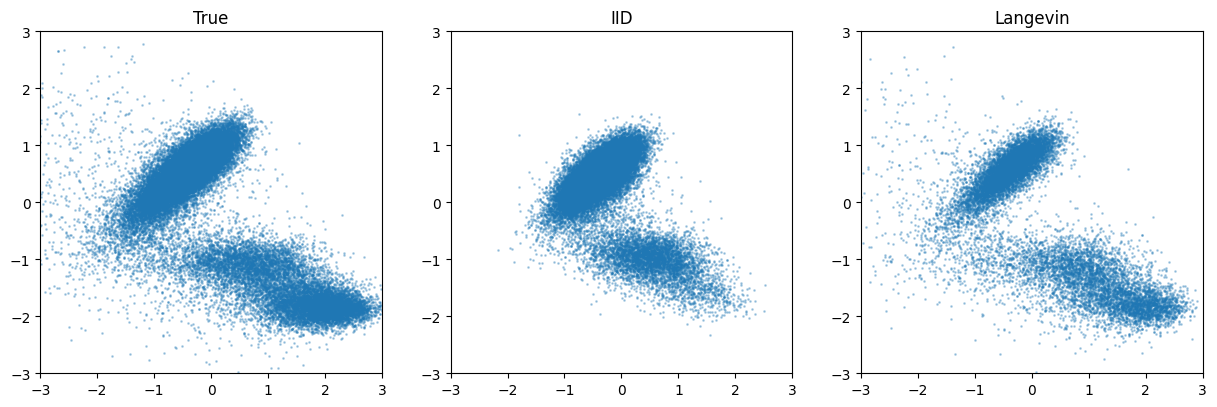

In [8]:
true_samples = dataset.samples 



iid_samples = fp_sampler.iid_sampler(
    n_samples = 50000,
    device = DEVICE,
    store_trajectory = False,
    return_original_space = False
)


lan_samples = fp_sampler.langevin_simulator(
    n_parallel = 100,
    n_steps = 30000,
    dt = DT,
    mass = MASS,
    gamma = GAMMA,
    device = DEVICE,
    save_every = 100,
    burn_in_ratio = BURN_IN_RATIO,
    return_original_space = False
)





N = 50000

true_subset = true_samples[torch.randperm(len(true_samples))[:N]]
lan_subset = lan_samples[torch.randperm(len(lan_samples))[:N]]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

X_LIM = (-3, 3)
Y_LIM = (-3, 3)

for ax, (name, samples) in zip(axes, [
    ("True", true_subset),
    ("IID", iid_samples),
    ("Langevin", lan_subset)
]):
    x = samples[:, 0].cpu().numpy()
    y = samples[:, 1].cpu().numpy()

    ax.scatter(x, y, alpha=0.3, s=1)

    ax.set_xlim(X_LIM)
    ax.set_ylim(Y_LIM)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(name)


plt.savefig('fp_sampling.png')

### THIRD EXPERIMENT: KNOWLEDGE DISTILLATION
##### Once we have a trained original (trained) model on our 2D dataset, we can use it to generate trajectory data for distillation. Instead of running expensive simulations from scratch, the teacher predicts how each point moves over time, giving us reference trajectories quickly and efficiently. During distillation, the student model learns from these trajectories, trying to reproduce the teacher’s behavior while also minimizing other losses. We combine three key components into the total loss: a force loss that encourages the student to match the teacher’s local directions, a Fokker-Planck regularization that keeps the overall point distribution consistent, and a trajectory loss that directly compares the student’s simulated paths to the teacher’s. By training on these precomputed trajectories, the student can efficiently learn both short-term dynamics and long-term patterns, capturing the essence of the teacher while being much faster at generating new simulations.

In [20]:
# distilled (student) model
student_net = MullerBrownNet(
    input_dim = 2,
    time_embed_dim = 64,
    hidden_dim = 64,
    num_blocks = 2,
    activation ='silu'
)

c1 = torch.load('mb_dist_train/dist_epoch_150.pth')
student_net.load_state_dict(c1['student_energy_net_state'])

print("Number of original (teacher) model's parameters: ", sum(p.numel() for p in fp_net.parameters())) 
print("Number of distilled (student) model's parameters: ", sum(p.numel() for p in student_net.parameters())) 

Number of original (teacher) model's parameters:  134529
Number of distilled (student) model's parameters:  25921


In [18]:
# distillation optimizer which optimizes only student parameters
dist_optim = torch.optim.Adam([p for p in student_net.parameters()], lr=1e-5)

dist_trainer = MBDistillationTrainer(
    t_net = fp_net,
    s_net = student_net,
    fwd = fwd,
    data_loader = dataloader,
    optim = dist_optim,
    fp_gate = fp_gate,
    fp_loss = mb_fokker_planck_loss,
    dist_loss = mb_distillation_loss,
    score_fn = score_from_energy,
    fp_res = mb_heavy_fp_residual,
    epochs = 150,
    device = DEVICE,
    grad_acc = GRAD_ACC,
    checkpoint = 10,
    log_freq = 10,
    store_path = "./mb_dist_train",
    warmup_steps = 10000,
    fp_alpha = 5e-4,
    gate_params = {
            "k": 1.2, "snr_min": 0.5, "t_scale": 0.0,
            "sharpness": 5.0, "eps": 0.1
        },
    traj_freq = 10,
    eps_time = 1e-5,
    compute_trajectory_loss = False
)

In [ ]:
dist_losses = dist_trainer()

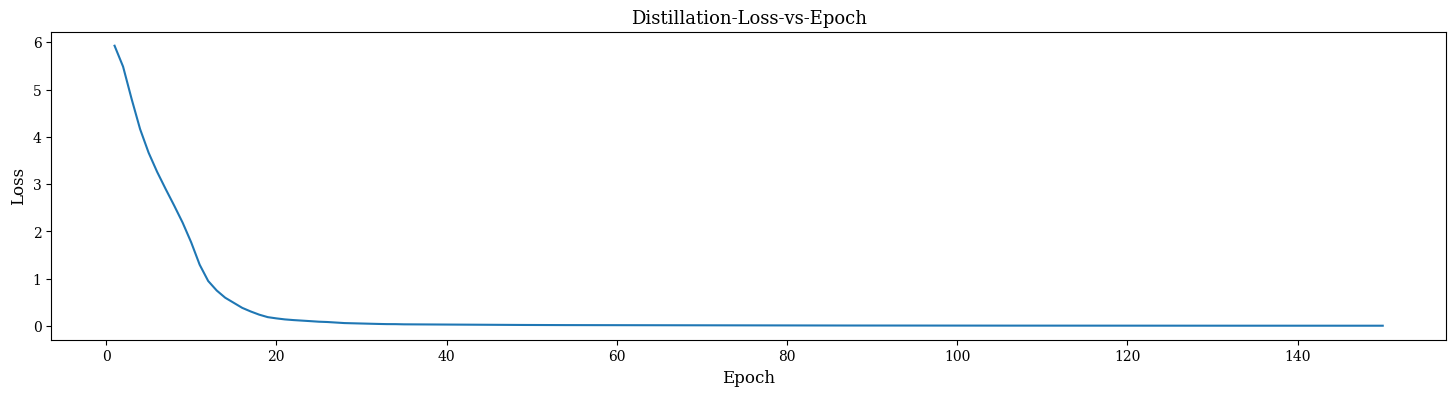

In [22]:
plt.figure(figsize=(18, 4))
plt.plot([i for i in range(1, 151)], dist_losses['total_losses'])
plt.title('Distillation-Loss-vs-Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

Generating IID samples from teacher model...


IID Sampling: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 999/999 [00:33<00:00, 29.94it/s]


Results saved to ./teacher_samples/sample_50000_iid.pth
Generating IID samples from student model...


IID Sampling: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 999/999 [00:15<00:00, 62.83it/s]


Results saved to ./student_samples/sample_50000_iid.pth
Generating Langevin samples from teacher model...


Langevin Simulation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30000/30000 [01:48<00:00, 276.97it/s]


Results saved to ./teacher_samples/sample_100_langevin.pth
Generating Langevin samples from student model...


Langevin Simulation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30000/30000 [01:29<00:00, 336.24it/s]


Results saved to ./student_samples/sample_100_langevin.pth
Saving figure...
Figures saved: ts_comparison.png and ts_comparison.pdf


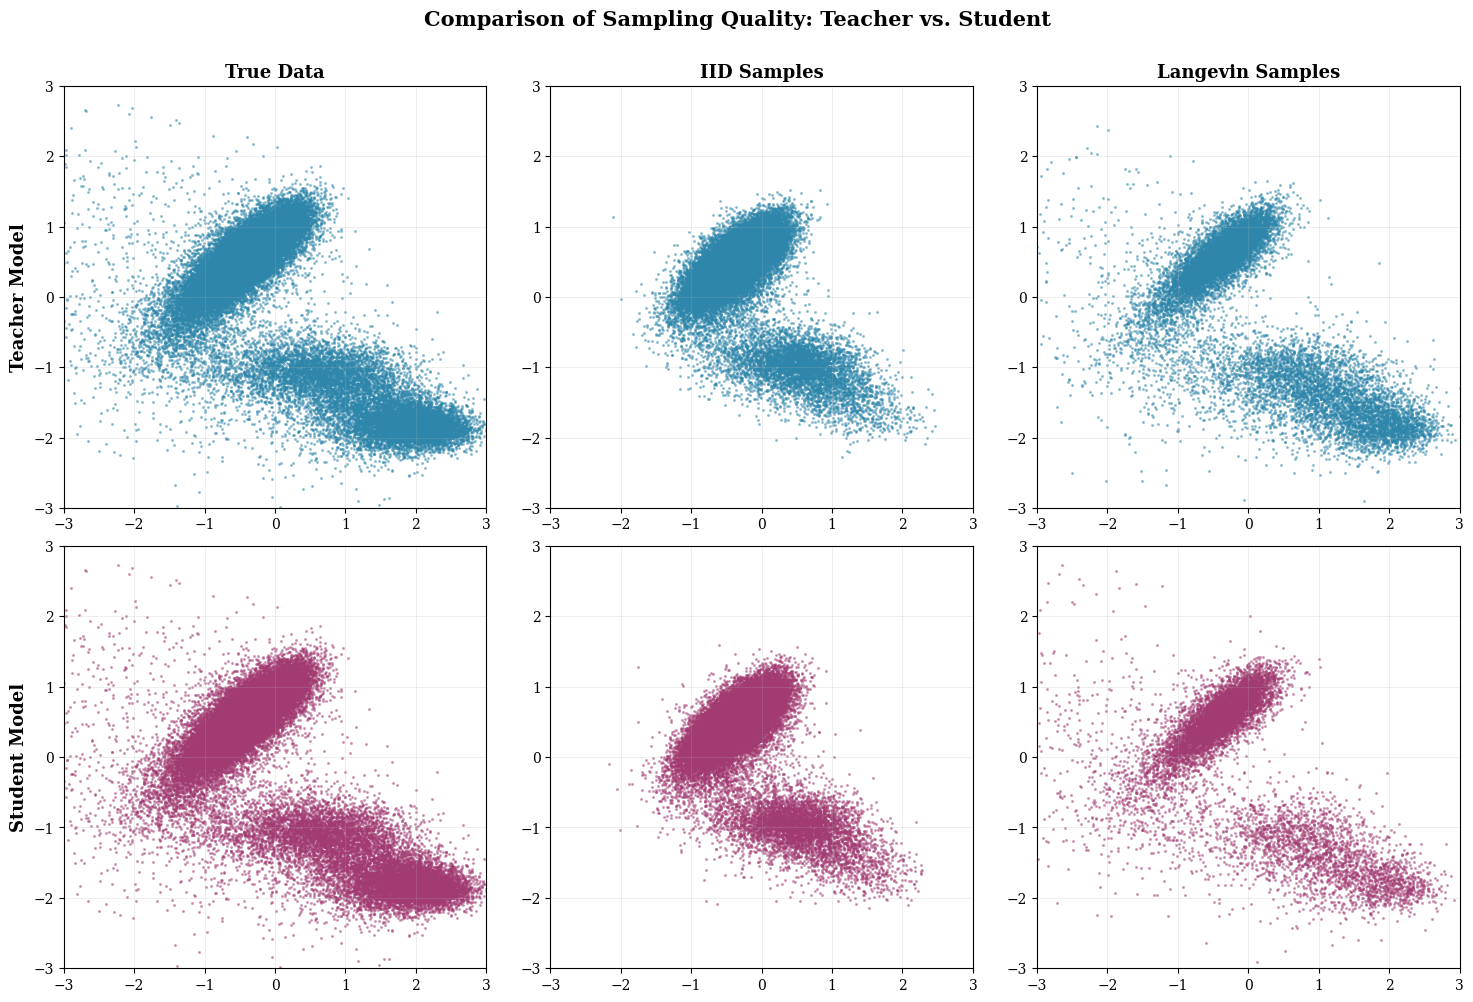


Quantitative Comparison:

True Data:
  Mean: [-0.0014, -0.0002]
  Std:  [0.9972, 0.9978]

Teacher (IID):
  Mean: [-0.2649, 0.3358]
  Std:  [0.4570, 0.5649]

Student (IID):
  Mean: [-0.2709, 0.3376]
  Std:  [0.4524, 0.5605]

Teacher (Langevin):
  Mean: [0.1186, -0.2489]
  Std:  [1.0807, 1.0616]

Student (Langevin):
  Mean: [-19.3412, -1.0130]
  Std:  [39.8343, 40.4186]


In [23]:

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 14


rev = ReverseVP(vs)

teacher_sampler = MBSampler(
    model=fp_net,
    rev=rev,
    dataset_mean=dataset.mean,
    dataset_std=dataset.std,
    eps_time=EPS_TIME,
    store_path="./teacher_samples",
    kbt=KBT
)


student_sampler = MBSampler(
    model=student_net,
    rev=rev,
    dataset_mean=dataset.mean,
    dataset_std=dataset.std,
    eps_time=EPS_TIME,
    store_path="./student_samples",
    kbt=KBT
)

true_samples = dataset.samples
N = 50000
true_subset = true_samples[torch.randperm(len(true_samples))[:N]]


print("Generating IID samples from teacher model...")
t_iid_samples = teacher_sampler.iid_sampler(
    n_samples=50000,
    device=DEVICE,
    store_trajectory=False,
    return_original_space=False
)

print("Generating IID samples from student model...")
s_iid_samples = student_sampler.iid_sampler(
    n_samples=50000,
    device=DEVICE,
    store_trajectory=False,
    return_original_space=False
)

print("Generating Langevin samples from teacher model...")
t_lan_samples = teacher_sampler.langevin_simulator(
    n_parallel=100,
    n_steps=30000,
    dt=DT,
    mass=MASS,
    gamma=GAMMA,
    device=DEVICE,
    save_every=100,
    burn_in_ratio=BURN_IN_RATIO,
    return_original_space=False
)

print("Generating Langevin samples from student model...")
s_lan_samples = student_sampler.langevin_simulator(
    n_parallel=100,
    n_steps=30000,
    dt=DT,
    mass=MASS,
    gamma=GAMMA,
    device=DEVICE,
    save_every=100,
    burn_in_ratio=BURN_IN_RATIO,
    return_original_space=False
)

t_lan_subset = t_lan_samples[torch.randperm(len(t_lan_samples))[:N]]
s_lan_subset = s_lan_samples[torch.randperm(len(s_lan_samples))[:N]]


fig, axes = plt.subplots(2, 3, figsize=(15, 10))

X_LIM = (-3, 3)
Y_LIM = (-3, 3)

scatter_params = {
    'alpha': 0.4,
    's': 1.5,
    'rasterized': True 
}

row_titles = ['Teacher Model', 'Student Model']
col_titles = ['True Data', 'IID Samples', 'Langevin Samples']


for ax, (title, samples) in zip(axes[0], [
    (col_titles[0], true_subset),
    (col_titles[1], t_iid_samples),
    (col_titles[2], t_lan_subset)
]):
    x = samples[:, 0].cpu().numpy()
    y = samples[:, 1].cpu().numpy()
    
    ax.scatter(x, y, c='#2E86AB', **scatter_params)
    ax.set_xlim(X_LIM)
    ax.set_ylim(Y_LIM)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(title, fontweight='bold')
    ax.grid(True, alpha=0.3, linewidth=0.5)
    
    if title == col_titles[0]:
        ax.set_ylabel(row_titles[0], fontsize=13, fontweight='bold')

for ax, (title, samples) in zip(axes[1], [
    (col_titles[0], true_subset),
    (col_titles[1], s_iid_samples),
    (col_titles[2], s_lan_subset)
]):
    x = samples[:, 0].cpu().numpy()
    y = samples[:, 1].cpu().numpy()
    
    ax.scatter(x, y, c='#A23B72', **scatter_params)
    ax.set_xlim(X_LIM)
    ax.set_ylim(Y_LIM)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.3, linewidth=0.5)
    
    if title == col_titles[0]:
        ax.set_ylabel(row_titles[1], fontsize=13, fontweight='bold')
    
    #ax.set_xlabel('$x_1$', fontsize=11)


#for ax in axes[0]:
    #ax.set_xlabel('$x_1$', fontsize=11)

fig.suptitle('Comparison of Sampling Quality: Teacher vs. Student', 
             fontsize=15, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.99])

print("Saving figure...")
plt.savefig('ts_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('ts_comparison.pdf', dpi=300, bbox_inches='tight')
print("Figures saved: ts_comparison.png and ts_comparison.pdf")

plt.show()

print("\n" + "="*60)
print("Quantitative Comparison:")
print("="*60)

def compute_stats(samples, name):
    """Compute basic statistics for samples"""
    samples_np = samples.cpu().numpy()
    print(f"\n{name}:")
    print(f"  Mean: [{samples_np[:, 0].mean():.4f}, {samples_np[:, 1].mean():.4f}]")
    print(f"  Std:  [{samples_np[:, 0].std():.4f}, {samples_np[:, 1].std():.4f}]")
    
compute_stats(true_subset, "True Data")
compute_stats(t_iid_samples, "Teacher (IID)")
compute_stats(s_iid_samples, "Student (IID)")
compute_stats(t_lan_subset, "Teacher (Langevin)")
compute_stats(s_lan_subset, "Student (Langevin)")

In [18]:

from matplotlib.animation import FuncAnimation, PillowWriter, FFMpegWriter


# ============================================================================
# CONFIGURATION - Edit these parameters
# ============================================================================

# Model paths (if loading from files)
# FP_MODEL_PATH = 'path/to/fp_model.pth'
# FP_FREE_MODEL_PATH = 'path/to/fp_free_model.pth'

# Or use already loaded models in memory:
# fp_net = your_loaded_fp_model
# fp_free_net = your_loaded_fp_free_model

# Animation settings
ANIMATION_SETTINGS = {
    'fps': 20,                    # Frames per second (15-30 recommended)
    'dpi': 150,                   # Resolution (100-200 recommended)
    'n_samples': 50000,           # Number of particles to visualize
    'output_name': 'sampling_animation',  # Output filename (no extension)
}

# Visual settings
VISUAL_SETTINGS = {
    'x_lim': (-3, 3),
    'y_lim': (-3, 3),
    'alpha': 0.25,                # Lower transparency for dense plots
    'point_size': 1,              # Smaller points for many samples
    'colors': {
        'fp_reg': '#2E86AB',      # Blue
        'fp_free': '#A23B72',     # Purple
        'true': '#23CE6B'         # Green
    }
}

# ============================================================================
# ANIMATION FUNCTION
# ============================================================================

def quick_animation(fp_trajectory, fp_free_trajectory, true_samples, settings):
    """
    Quick and simple animation generator
    
    Args:
        fp_trajectory: (n_frames, n_samples, 2)
        fp_free_trajectory: (n_frames, n_samples, 2)
        true_samples: (n_samples, 2)
        settings: dict with animation parameters
    """
    print("\n🎬 Creating animation...")
    
    # Setup
    n_frames = min(fp_trajectory.shape[0], fp_free_trajectory.shape[0])
    fp_trajectory = fp_trajectory#[:n_frames]
    fp_free_trajectory = fp_free_trajectory#[:n_frames]
    
    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Sampling Process Comparison', fontsize=15, fontweight='bold', y=0.98)
    
    titles = ['Teacher Distribution', 'Student Distribution', 'True Distribution']
    data_list = [None, None, true_samples]
    
    scatters = []
    for ax, title, color_key, data in zip(axes, titles, 
                                           ['fp_reg', 'fp_free', 'true'], 
                                           data_list):
        ax.set_xlim(VISUAL_SETTINGS['x_lim'])
        ax.set_ylim(VISUAL_SETTINGS['y_lim'])
        ax.set_aspect('equal')
        ax.set_title(title, fontweight='bold', fontsize=13)
        ax.set_xlabel('$x_1$', fontsize=11)
        ax.set_ylabel('$x_2$', fontsize=11)
        ax.grid(True, alpha=0.3)
        
        if data is not None:
            # Static true data
            ax.scatter(data[:, 0].cpu().numpy(), 
                      data[:, 1].cpu().numpy(),
                      alpha=VISUAL_SETTINGS['alpha'],
                      s=VISUAL_SETTINGS['point_size'],
                      c=VISUAL_SETTINGS['colors'][color_key],
                      rasterized=True)
            scatters.append(None)
        else:
            # Dynamic plots
            scatter = ax.scatter([], [], 
                               alpha=VISUAL_SETTINGS['alpha'],
                               s=VISUAL_SETTINGS['point_size'],
                               c=VISUAL_SETTINGS['colors'][color_key],
                               rasterized=True)
            scatters.append(scatter)
    
    progress_text = fig.text(0.5, 0.92, '', ha='center', fontsize=11, 
                            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    def init():
        for scatter in scatters[:2]:
            if scatter is not None:
                scatter.set_offsets(np.empty((0, 2)))
        progress_text.set_text('')
        return [s for s in scatters[:2] if s is not None] + [progress_text]
    
    def update(frame):
        # Update FP-regularized
        if scatters[0] is not None:
            data = fp_trajectory[frame].cpu().numpy()
            scatters[0].set_offsets(data)
        
        # Update FP-free
        if scatters[1] is not None:
            data = fp_free_trajectory[frame].cpu().numpy()
            scatters[1].set_offsets(data)
        
        # Update progress
        progress = (frame / n_frames) * 100
        t_value = 1.0 - (frame / n_frames)
        progress_text.set_text(
            f'Progress: {progress:.1f}% | t = {t_value:.3f} | Frame {frame+1}/{n_frames}'
        )
        
        return [s for s in scatters[:2] if s is not None] + [progress_text]
    
    # Create animation
    print(f"  ⏳ Rendering {n_frames} frames at {settings['fps']} fps...")
    anim = FuncAnimation(fig, update, init_func=init, frames=n_frames,
                        interval=1000/settings['fps'], blit=True, repeat=True)
    
    # Save GIF
    output_base = settings['output_name']
    print(f"  💾 Saving GIF...")
    gif_writer = PillowWriter(fps=settings['fps'])
    anim.save(f'{output_base}.gif', writer=gif_writer, dpi=settings['dpi'])
    print(f"  ✅ Saved: {output_base}.gif")
    
    # Try MP4
    try:
        print(f"  💾 Saving MP4...")
        mp4_writer = FFMpegWriter(fps=settings['fps'], bitrate=2000)
        anim.save(f'{output_base}.mp4', writer=mp4_writer, dpi=settings['dpi'])
        print(f"  ✅ Saved: {output_base}.mp4")
    except:
        print(f"  ⚠️  MP4 not saved (ffmpeg not available)")
    
    plt.close()
    print("  🎉 Done!\n")
    
    return anim


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """Main execution - run this!"""
    
    print("="*70)
    print("  🎬 QUICK START ANIMATION GENERATOR")
    print("="*70)
    
    # ========================================================================
    # Step 1: Setup samplers
    # ========================================================================
    print("\n[1/3] Setting up samplers...")
    
    rev = ReverseVP(vs)
    
    fp_sampler = MBSampler(
        model=fp_net,
        rev=rev,
        dataset_mean=dataset.mean,
        dataset_std=dataset.std,
        eps_time=EPS_TIME,
        store_path="./fp_samples11",
        kbt=KBT
    )
    
    fp_free_sampler = MBSampler(
        model=student_net,
        rev=rev,
        dataset_mean=dataset.mean,
        dataset_std=dataset.std,
        eps_time=EPS_TIME,
        store_path="./fp_free_samples11",
        kbt=KBT
    )
    
    print("  ✅ Samplers ready")
    
    # ========================================================================
    # Step 2: Generate trajectories
    # ========================================================================
    print("\n[2/3] Generating sampling trajectories...")
    print("  This may take a few minutes...")
    
    # FP-regularized
    print("\n  📊 FP-Regularized model...")
    fp_sampler.iid_sampler(
        n_samples=ANIMATION_SETTINGS['n_samples'],
        dt = 0.001,
        device=DEVICE,
        store_trajectory=True,
        return_original_space=False
    )
    
    # FP-free
    print("\n  📊 FP-Free model...")
    fp_free_sampler.iid_sampler(
        n_samples=ANIMATION_SETTINGS['n_samples'],
        dt = 0.001,
        device=DEVICE,
        store_trajectory=True,
        return_original_space=False
    )
    
    # Load results
    import os
    fp_results = torch.load(os.path.join("./fp_samples11", 
                            f"sample_{ANIMATION_SETTINGS['n_samples']}_iid.pth"))
    fp_free_results = torch.load(os.path.join("./fp_free_samples11", 
                                 f"sample_{ANIMATION_SETTINGS['n_samples']}_iid.pth"))
    
    fp_trajectory = fp_results['trajectory']
    fp_free_trajectory = fp_free_results['trajectory']
    
    print(f"\n  ✅ Trajectories generated")
    print(f"     FP-Reg: {fp_trajectory.shape[0]} frames")
    print(f"     FP-Free: {fp_free_trajectory.shape[0]} frames")
    
    # Get true samples (use all available data)
    true_samples = dataset.samples
    print(f"     Using all {len(true_samples)} true samples for comparison")
    
    # ========================================================================
    # Step 3: Create animation
    # ========================================================================
    print("\n[3/3] Creating animation...")
    
    anim = quick_animation(
        fp_trajectory=fp_trajectory,
        fp_free_trajectory=fp_free_trajectory,
        true_samples=true_samples,
        settings=ANIMATION_SETTINGS
    )
    
    # ========================================================================
    # Done!
    # ========================================================================
    print("="*70)
    print("  ✨ ALL DONE!")
    print("="*70)
    print(f"\n  Your animations are ready:")
    print(f"  📁 {ANIMATION_SETTINGS['output_name']}.gif")
    print(f"  📁 {ANIMATION_SETTINGS['output_name']}.mp4 (if ffmpeg available)")
    print("\n  Tip: Adjust settings at the top of this script to customize!")
    print("="*70 + "\n")


In [19]:
main()

  🎬 QUICK START ANIMATION GENERATOR

[1/3] Setting up samplers...
  ✅ Samplers ready

[2/3] Generating sampling trajectories...
  This may take a few minutes...

  📊 FP-Regularized model...


IID Sampling: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1999/1999 [01:09<00:00, 28.92it/s]


Results saved to ./fp_samples11/sample_50000_iid.pth

  📊 FP-Free model...


IID Sampling: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1999/1999 [00:33<00:00, 59.66it/s]


Results saved to ./fp_free_samples11/sample_50000_iid.pth

  ✅ Trajectories generated
     FP-Reg: 1550 frames
     FP-Free: 1550 frames
     Using all 100000 true samples for comparison

[3/3] Creating animation...

🎬 Creating animation...
  ⏳ Rendering 1550 frames at 20 fps...
  💾 Saving GIF...
  ✅ Saved: sampling_animation.gif
  💾 Saving MP4...
  ⚠️  MP4 not saved (ffmpeg not available)
  🎉 Done!

  ✨ ALL DONE!

  Your animations are ready:
  📁 sampling_animation.gif
  📁 sampling_animation.mp4 (if ffmpeg available)

  Tip: Adjust settings at the top of this script to customize!

